# **Installing Libraries**

In [ ]:
pip install transformers torch pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 74.3 MB/s eta 0:00:00


In [ ]:
pip install -q mne==1.12.1 scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 141.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
pip install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 50.7 MB/s eta 0:00:00


# **Importing Libraries**

In [ ]:
import lightning as L
import pandas as pd
import re
from transformers import get_linear_schedule_with_warmup
import torch
from torch.utils.data import Dataset
import lightning as L
import torch.nn as nn
from torch.utils.data import DataLoader
from lightning.pytorch.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassF1Score,
    MulticlassCohenKappa
)
from pathlib import Path

import mne
import numpy as np
from scipy.io import loadmat
from scipy.signal import cheby2, sosfiltfilt
from google.colab import drive

# **Loading the Dataset**

In [ ]:
drive.mount("/content/drive")

gdf_path = "/content/drive/MyDrive/BCI_data/A01T.gdf"

Mounted at /content/drive


In [ ]:
GDF_DIR = Path(
    "/content/drive/MyDrive/BCI_data"
)

LABEL_DIR = Path(
    "/content/drive/MyDrive/BCI_data_label"
)

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/EEG_Conformer/processed_train"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SUBJECTS = range(1, 10)

SFREQ = 250
N_CHANNELS = 22
N_SAMPLES = 1000

In [ ]:
# Sixth-order Chebyshev (4–40 Hz)
sos = cheby2(
    N=6,
    rs=60,
    Wn=[4, 40],
    btype="bandpass",
    fs=SFREQ,
    output="sos",
)

In [ ]:
def load_training_gdf(filepath):
    raw = mne.io.read_raw_gdf(
        filepath,
        preload=True,
        verbose=False
    )

    eeg = raw.get_data()[:N_CHANNELS]

    # Event code --> class label
    class_map = {
        "769": 0,  # left hand
        "770": 1,  # right hand
        "771": 2,  # both feet
        "772": 3,  # tongue
    }

    cue_events = []

    for onset, description in zip(
        raw.annotations.onset,
        raw.annotations.description
    ):
        description = str(description)

        if description in class_map:
            cue_sample = int(round(onset * SFREQ))
            label = class_map[description]
            cue_events.append((cue_sample, label))

    trials = []
    labels = []

    # Cue occurs 2 seconds after trial start.
    # Extracting 0–4 seconds
    for cue_sample, label in cue_events:
        start = cue_sample
        stop = start + N_SAMPLES

        if stop > eeg.shape[1]:
            continue

        trial = eeg[:, start:stop]

        if trial.shape == (N_CHANNELS, N_SAMPLES):
            trials.append(trial)
            labels.append(label)

    X = np.stack(trials)
    y = np.asarray(labels, dtype=np.int64)

    X = np.nan_to_num(
        X,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return X, y


def load_evaluation_gdf(filepath, label_filepath):
    raw = mne.io.read_raw_gdf(
        filepath,
        preload=True,
        verbose=False
    )

    eeg = raw.get_data()[:N_CHANNELS]

    cue_samples = []

    for onset, description in zip(
        raw.annotations.onset,
        raw.annotations.description
    ):
        if str(description) == "783":
            cue_samples.append(int(round(onset * SFREQ)))

    trials = []

    for cue_sample in cue_samples:
        start = cue_sample
        stop = start + N_SAMPLES

        if stop > eeg.shape[1]:
            continue

        trial = eeg[:, start:stop]

        if trial.shape == (N_CHANNELS, N_SAMPLES):
            trials.append(trial)

    X = np.stack(trials)
    X = np.nan_to_num(
        X,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    label_data = loadmat(label_filepath)

    if "classlabel" not in label_data:
        raise KeyError(
            f"'classlabel' was not found in {Path(label_filepath).name}"
        )

    y = np.asarray(label_data["classlabel"]).squeeze().astype(np.int64)

    if y.min() == 1 and y.max() == 4:
        y = y - 1

    if len(X) != len(y):
        raise ValueError(
            f"Trial/label mismatch for {Path(filepath).name}: "
            f"{len(X)} trials and {len(y)} labels"
        )

    return X, y

In [ ]:
# applying chebyshev filter
def filter_trials(X):
    X_filtered = sosfiltfilt(
        sos,
        X,
        axis=-1
    )

    X_filtered = np.nan_to_num(
        X_filtered,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return X_filtered.astype(np.float32)

In [ ]:
subject_data = {}
summary = []

for subject in SUBJECTS:
    train_filename = f"A0{subject}T.gdf"
    test_filename = f"A0{subject}E.gdf"
    test_label_filename = f"A0{subject}E.mat"

    train_filepath = GDF_DIR / train_filename
    test_filepath = GDF_DIR / test_filename
    test_label_filepath = LABEL_DIR / test_label_filename

    if not train_filepath.exists():
        print(f"Missing: {train_filepath}")
        continue

    if not test_filepath.exists():
        print(f"Missing: {test_filepath}")
        continue

    if not test_label_filepath.exists():
        print(f"Missing: {test_label_filepath}")
        continue

    print(f"\nProcessing Subject A0{subject}")

    X_train, y_train = load_training_gdf(str(train_filepath))
    X_test, y_test = load_evaluation_gdf(
        str(test_filepath),
        str(test_label_filepath)
    )

    print("T-session before filtering:", X_train.shape, y_train.shape)
    print("E-session before filtering:", X_test.shape, y_test.shape)

    X_train = filter_trials(X_train)
    X_test = filter_trials(X_test)

    mean = X_train.mean()
    std = X_train.std()

    if std < 1e-8:
        raise ValueError(f"Invalid standard deviation for {train_filename}")

    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std

    X_train = X_train[:, np.newaxis, :, :].astype(np.float32)
    X_test = X_test[:, np.newaxis, :, :].astype(np.float32)

    subject_data[subject] = {
        "X_train": X_train,
        "y_train": y_train.astype(np.int64),
        "X_test": X_test,
        "y_test": y_test.astype(np.int64),
    }

    output_path = OUTPUT_DIR / f"A0{subject}_processed.npz"

    np.savez_compressed(
        output_path,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        mean=np.float32(mean),
        std=np.float32(std),
        subject=np.int64(subject),
        sampling_rate=np.float32(SFREQ)
    )

    print("Train shape:", X_train.shape, y_train.shape)
    print("Test shape:", X_test.shape, y_test.shape)
    print("Saved:", output_path)

    summary.append(
        (
            subject,
            X_train.shape,
            X_test.shape
        )
    )

print("\nSubject-wise preprocessing summary")
for subject, train_shape, test_shape in summary:
    print(
        f"A0{subject} | Train: {train_shape} | Test: {test_shape}"
    )



Processing Subject A01


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


T-session before filtering: (288, 22, 1000) (288,)
E-session before filtering: (288, 22, 1000) (288,)
Train shape: (288, 1, 22, 1000) (288,)
Test shape: (288, 1, 22, 1000) (288,)
Saved: /content/drive/MyDrive/EEG_Conformer/processed_train/A01_processed.npz

Processing Subject A02


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


T-session before filtering: (288, 22, 1000) (288,)
E-session before filtering: (288, 22, 1000) (288,)
Train shape: (288, 1, 22, 1000) (288,)
Test shape: (288, 1, 22, 1000) (288,)
Saved: /content/drive/MyDrive/EEG_Conformer/processed_train/A02_processed.npz

Processing Subject A03


...

T-session before filtering: (288, 22, 1000) (288,)
E-session before filtering: (288, 22, 1000) (288,)
Train shape: (288, 1, 22, 1000) (288,)
Test shape: (288, 1, 22, 1000) (288,)
Saved: /content/drive/MyDrive/EEG_Conformer/processed_train/A07_processed.npz

Processing Subject A08


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


T-session before filtering: (288, 22, 1000) (288,)
E-session before filtering: (288, 22, 1000) (288,)
Train shape: (288, 1, 22, 1000) (288,)
Test shape: (288, 1, 22, 1000) (288,)
Saved: /content/drive/MyDrive/EEG_Conformer/processed_train/A08_processed.npz

Processing Subject A09


/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/usr/lib/python3.12/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


T-session before filtering: (288, 22, 1000) (288,)
E-session before filtering: (288, 22, 1000) (288,)
Train shape: (288, 1, 22, 1000) (288,)
Test shape: (288, 1, 22, 1000) (288,)
Saved: /content/drive/MyDrive/EEG_Conformer/processed_train/A09_processed.npz

Subject-wise preprocessing summary
A01 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A02 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A03 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A04 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A05 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A06 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A07 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A08 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A09 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)


In [ ]:
example_subject = 1

print("Training:", subject_data[example_subject]["X_train"].shape,
      subject_data[example_subject]["y_train"].shape)
print("Test:", subject_data[example_subject]["X_test"].shape,
      subject_data[example_subject]["y_test"].shape)


Training: (288, 1, 22, 1000) (288,)
Test: (288, 1, 22, 1000) (288,)


# **Main Model**

In [ ]:
      #  "769": 0,  # left hand
      #   "770": 1,  # right hand
      #   "771": 2,  # both feet
      #   "772": 3,  # tongue

In [ ]:
# EEG-Conformer-style Transformer.

class MultiHeadAttention(nn.Module):
    def __init__(self, model_dim=40, nhead=10, dropout=0.5):
        super().__init__()

        self.model_dim = model_dim
        self.nhead = nhead
        self.head_dim = model_dim // nhead

        self.keys = nn.Linear(model_dim, model_dim)
        self.queries = nn.Linear(model_dim, model_dim)
        self.values = nn.Linear(model_dim, model_dim)

        self.attn_dropout = nn.Dropout(dropout)
        self.projection = nn.Linear(model_dim, model_dim)

    def forward(self, x):
        batch_size, sequence_length, _ = x.shape

        queries = self.queries(x).view(
            batch_size, sequence_length, self.nhead, self.head_dim
        ).transpose(1, 2)

        keys = self.keys(x).view(
            batch_size, sequence_length, self.nhead, self.head_dim
        ).transpose(1, 2)

        values = self.values(x).view(
            batch_size, sequence_length, self.nhead, self.head_dim
        ).transpose(1, 2)

        energy = torch.matmul(queries, keys.transpose(-2, -1))

        attention = torch.softmax(energy / (self.model_dim ** 0.5), dim=-1)
        attention = self.attn_dropout(attention)

        output = torch.matmul(attention, values)
        output = output.transpose(1, 2).contiguous().view(
            batch_size, sequence_length, self.model_dim
        )

        return self.projection(output)


class PreLNTransformerLayer(nn.Module):
    def __init__(
        self,
        model_dim=40,
        nhead=10,
        dropout=0.5,
        expansion=4
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(model_dim)
        self.self_attn = MultiHeadAttention(
            model_dim=model_dim,
            nhead=nhead,
            dropout=dropout
        )
        self.dropout1 = nn.Dropout(dropout)

        self.norm2 = nn.LayerNorm(model_dim)

        self.ffn = nn.Sequential(
            nn.Linear(model_dim, expansion * model_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(expansion * model_dim, model_dim),
        )
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        x = x + self.dropout1(self.self_attn(self.norm1(x)))
        x = x + self.dropout2(self.ffn(self.norm2(x)))
        return x


class Transformer_full(nn.Module):

    def __init__(
        self,
        model_dim=40,
        nhead=10,
        num_layers=6,
        dropout=0.5
    ):
        super().__init__()

        self.layers = nn.ModuleList([
            PreLNTransformerLayer(
                model_dim=model_dim,
                nhead=nhead,
                dropout=dropout,
                expansion=4
            )
            for _ in range(num_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


In [ ]:
# 9 subjects
for subject in sorted(subject_data):
    data = subject_data[subject]
    print(
        f"A0{subject} | "
        f"Train: {data['X_train'].shape} | "
        f"Test: {data['X_test'].shape}"
    )


A01 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A02 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A03 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A04 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A05 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A06 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A07 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A08 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)
A09 | Train: (288, 1, 22, 1000) | Test: (288, 1, 22, 1000)


In [ ]:
BATCH_SIZE = 72

In [ ]:
class EEG_Conformer(L.LightningModule):
    def __init__(
        self,
        lr=2e-4,
        dropout_rate=0.5,
        augmentation_data=None,
        augmentation_labels=None,
        augmentation_batch_size=72
    ):
        super().__init__()

        self.save_hyperparameters(
            ignore=["augmentation_data", "augmentation_labels"]
        )

        self.lr = lr
        self.augmentation_batch_size = augmentation_batch_size
        self.augmentation_data = augmentation_data
        self.augmentation_labels = augmentation_labels

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=40,
                kernel_size=(1, 25),
                stride=(1, 1)
            ),
            nn.Conv2d(
                in_channels=40,
                out_channels=40,
                kernel_size=(22, 1),
                stride=(1, 1)
            ),
            nn.BatchNorm2d(40),
            nn.ELU(),
            nn.AvgPool2d(
                kernel_size=(1, 75),
                stride=(1, 15)
            ),
            nn.Dropout(dropout_rate)
        )

        self.projection_conv = nn.Conv2d(
            in_channels=40,
            out_channels=40,
            kernel_size=(1, 1),
            stride=(1, 1)
        )

        self.transformer = Transformer_full(
            model_dim=40,
            nhead=10,
            num_layers=6,
            dropout=dropout_rate
        )

        self.classifier = nn.Sequential(
            nn.Linear(61 * 40, 256),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(256, 32),
            nn.ELU(),
            nn.Dropout(0.3),
            nn.Linear(32, 4)
        )

        self.loss_fn = nn.CrossEntropyLoss()

        self.train_accuracy = MulticlassAccuracy(num_classes=4)
        self.test_accuracy = MulticlassAccuracy(num_classes=4)

        self.test_preds = []
        self.test_labels = []

    def forward(self, x):
        x = self.conv(x)
        x = self.projection_conv(x)
        x = x.squeeze(2).transpose(1, 2)
        x = self.transformer(x)

        embedding = x.flatten(start_dim=1)
        logits = self.classifier(embedding)

        return embedding, logits

    def segmentation_reconstruction(self, device):
        if self.augmentation_data is None or self.augmentation_labels is None:
            return None, None

        aug_data = []
        aug_label = []

        for cls4aug in range(4):
            cls_idx = np.where(self.augmentation_labels == cls4aug)[0]
            tmp_data = self.augmentation_data[cls_idx]
            tmp_label = self.augmentation_labels[cls_idx]

            tmp_aug_data = np.zeros(
                (
                    int(self.augmentation_batch_size / 4),
                    1,
                    22,
                    1000
                ),
                dtype=np.float32
            )

            for ri in range(int(self.augmentation_batch_size / 4)):
                for rj in range(8):
                    rand_idx = np.random.randint(
                        0,
                        tmp_data.shape[0],
                        8
                    )

                    tmp_aug_data[
                        ri,
                        :,
                        :,
                        rj * 125:(rj + 1) * 125
                    ] = tmp_data[
                        rand_idx[rj],
                        :,
                        :,
                        rj * 125:(rj + 1) * 125
                    ]

            aug_data.append(tmp_aug_data)

            aug_label.append(
                tmp_label[:int(self.augmentation_batch_size / 4)]
            )

        aug_data = np.concatenate(aug_data)
        aug_label = np.concatenate(aug_label)

        aug_shuffle = np.random.permutation(len(aug_data))
        aug_data = aug_data[aug_shuffle]
        aug_label = aug_label[aug_shuffle]

        aug_data = torch.from_numpy(aug_data).to(
            device=device,
            dtype=torch.float32
        )

        aug_label = torch.from_numpy(aug_label).to(
            device=device,
            dtype=torch.long
        )

        return aug_data, aug_label

    @staticmethod
    def unpack_batch(batch):
        x, y = batch
        return x.float(), y.long()

    def training_step(self, batch, batch_idx):
        x, y = self.unpack_batch(batch)

        aug_x, aug_y = self.segmentation_reconstruction(
            device=x.device
        )

        if aug_x is not None:
            x = torch.cat((x, aug_x), dim=0)
            y = torch.cat((y, aug_y), dim=0)

        _, logits = self(x)
        loss = self.loss_fn(logits, y)

        preds = torch.argmax(logits, dim=1)
        self.train_accuracy.update(preds, y)

        self.log(
            "train_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=x.size(0)
        )

        self.log(
            "train_accuracy",
            self.train_accuracy,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=x.size(0)
        )

        return loss

    def test_step(self, batch, batch_idx):
        x, y = self.unpack_batch(batch)

        _, logits = self(x)
        loss = self.loss_fn(logits, y)

        preds = torch.argmax(logits, dim=1)

        self.test_accuracy.update(preds, y)

        self.test_preds.append(preds.detach().cpu())
        self.test_labels.append(y.detach().cpu())

        self.log(
            "test_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=x.size(0)
        )

        self.log(
            "test_accuracy",
            self.test_accuracy,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=x.size(0)
        )

        return loss

    def on_test_epoch_start(self):
        self.test_preds = []
        self.test_labels = []
        self.test_accuracy.reset()

    def on_test_epoch_end(self):
        self.all_test_preds = torch.cat(self.test_preds)
        self.all_test_labels = torch.cat(self.test_labels)

    def configure_optimizers(self):
        return torch.optim.Adam(
            self.parameters(),
            lr=self.lr,
            betas=(0.5, 0.999)
        )

# **Training**

In [ ]:
import random
import datetime
from torch.autograd import Variable

BATCH_SIZE = 72
N_EPOCHS = 800
LEARNING_RATE = 2e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

subject_results = []
all_best_y_true = []
all_best_y_pred = []

for subject in sorted(subject_data):
    starttime = datetime.datetime.now()

    seed_n = np.random.randint(2021)
    print("seed is", seed_n)

    random.seed(seed_n)
    np.random.seed(seed_n)
    torch.manual_seed(seed_n)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_n)
        torch.cuda.manual_seed_all(seed_n)

    print(f"\nSubject {subject}")

    data = subject_data[subject]

    X_train = torch.from_numpy(data["X_train"])
    y_train = torch.from_numpy(data["y_train"]).long()

    X_test = torch.from_numpy(data["X_test"]).to(device)
    y_test = torch.from_numpy(data["y_test"]).long().to(device)

    train_dataset = torch.utils.data.TensorDataset(
        X_train,
        y_train
    )

    train_dataloader = torch.utils.data.DataLoader(
        dataset=train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    model = EEG_Conformer(
        lr=LEARNING_RATE,
        dropout_rate=0.5,
        augmentation_data=data["X_train"],
        augmentation_labels=data["y_train"],
        augmentation_batch_size=BATCH_SIZE
    ).to(device)

    criterion_cls = torch.nn.CrossEntropyLoss().to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        betas=(0.5, 0.999)
    )

    bestAcc = 0.0
    averAcc = 0.0
    num = 0

    Y_true = None
    Y_pred = None

    for epoch in range(N_EPOCHS):

        model.train()

        for batch_idx, (img, label) in enumerate(train_dataloader):

            img = img.to(device=device, dtype=torch.float32)
            label = label.to(device=device, dtype=torch.long)

            aug_data, aug_label = model.segmentation_reconstruction(
                device=device
            )

            img = torch.cat((img, aug_data), dim=0)
            label = torch.cat((label, aug_label), dim=0)

            _, outputs = model(img)

            loss = criterion_cls(outputs, label)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()

        with torch.no_grad():
            _, cls = model(X_test)

            loss_test = criterion_cls(cls, y_test)

            y_pred = torch.max(cls, 1)[1]

            acc = float(
                (y_pred == y_test)
                .cpu()
                .numpy()
                .astype(int)
                .sum()
            ) / float(y_test.size(0))

            train_pred = torch.max(outputs, 1)[1]

            train_acc = float(
                (train_pred == label)
                .cpu()
                .numpy()
                .astype(int)
                .sum()
            ) / float(label.size(0))

        print(
            "Epoch:",
            epoch,
            " Train loss: %.6f" % loss.detach().cpu().numpy(),
            " Test loss: %.6f" % loss_test.detach().cpu().numpy(),
            " Train accuracy %.6f" % train_acc,
            " Test accuracy is %.6f" % acc
        )

        num += 1
        averAcc += acc

        if acc > bestAcc:
            bestAcc = acc
            Y_true = y_test.detach().cpu().clone()
            Y_pred = y_pred.detach().cpu().clone()

    averAcc = averAcc / num

    print("The average accuracy is:", averAcc)
    print("The best accuracy is:", bestAcc)

    subject_results.append({
        "subject": subject,
        "seed": seed_n,
        "best_accuracy": bestAcc,
        "average_accuracy": averAcc
    })

    all_best_y_true.append(Y_true)
    all_best_y_pred.append(Y_pred)

    endtime = datetime.datetime.now()
    print(
        f"subject {subject} duration:",
        str(endtime - starttime)
    )


Streaming output truncated to the last 5000 lines.
Epoch: 639  Train loss: 0.050603  Test loss: 1.792221  Train accuracy 0.979167  Test accuracy is 0.833333
Epoch: 640  Train loss: 0.082076  Test loss: 1.992031  Train accuracy 0.993056  Test accuracy is 0.788194
Epoch: 641  Train loss: 0.017645  Test loss: 1.017094  Train accuracy 0.993056  Test accuracy is 0.881944
Epoch: 642  Train loss: 0.066850  Test loss: 1.539499  Train accuracy 0.979167  Test accuracy is 0.861111
Epoch: 643  Train loss: 0.025253  Test loss: 1.021508  Train accuracy 0.986111  Test accuracy is 0.885417
Epoch: 644  Train loss: 0.046954  Test loss: 1.044707  Train accuracy 0.986111  Test accuracy is 0.888889
Epoch: 645  Train loss: 0.015473  Test loss: 1.046577  Train accuracy 0.993056  Test accuracy is 0.885417
Epoch: 646  Train loss: 0.094741  Test loss: 1.384016  Train accuracy 0.979167  Test accuracy is 0.861111
Epoch: 647  Train loss: 0.056105  Test loss: 1.374848  Train accuracy 0.993056  Test accuracy is 0.83

# **Results**

In [ ]:
results_df = pd.DataFrame(subject_results)

display(results_df)

print(
    "\nAverage Best accuracy:",
    results_df["best_accuracy"].mean()
)

print(
    "Average Average accuracy:",
    results_df["average_accuracy"].mean()
)


,subject,seed,best_accuracy,average_accuracy
0,1,1926,0.864583,0.768333
1,2,48,0.600694,0.478464
2,3,1540,0.920139,0.814436
3,4,776,0.781250,0.657396
4,5,1797,0.506944,0.397960
5,6,129,0.618056,0.539045
6,7,1343,0.916667,0.717708
7,8,868,0.840278,0.763698
8,9,871,0.843750,0.753928



Average Best accuracy: 0.7658179012345678
Average Average accuracy: 0.654551986882716


In [ ]:
all_test_labels = torch.cat(all_best_y_true)
all_test_preds = torch.cat(all_best_y_pred)

print("Combined labels:", all_test_labels.shape)
print("Combined predictions:", all_test_preds.shape)


Combined labels: torch.Size([2592])
Combined predictions: torch.Size([2592])


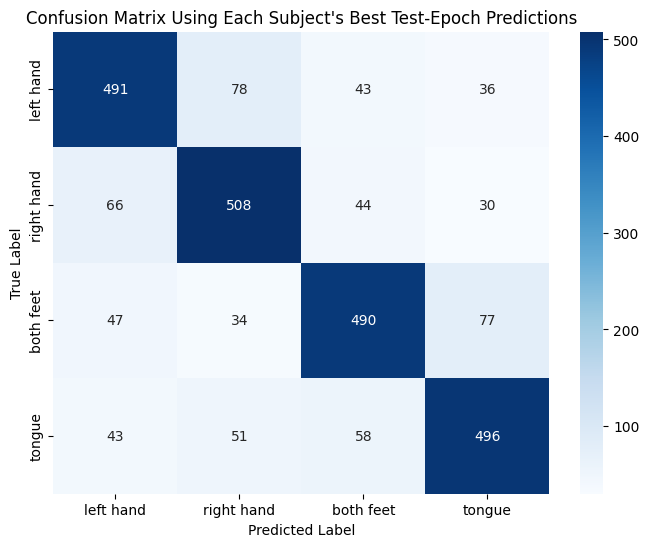

In [ ]:
# Confusion Matrix
from torchmetrics.classification import MulticlassConfusionMatrix
import seaborn as sns
import matplotlib.pyplot as plt

confmat = MulticlassConfusionMatrix(num_classes=4)
cm = confmat(all_test_preds, all_test_labels).numpy()

class_labels = [
    "left hand",
    "right hand",
    "both feet",
    "tongue"
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Using Each Subject's Best Test-Epoch Predictions")
plt.show()
